# Notebook 3 — Modelo LSTM (Red neuronal recurrente)

**Proyecto:** Sistema de pronóstico de demanda eléctrica en Ecuador

Implementación de una red LSTM con TensorFlow/Keras. Dado que la muestra es pequeña (60 observaciones, ~30 ventanas de entrenamiento), se aplican técnicas de regularización agresivas y se promedia el resultado de **múltiples corridas con distintas semillas** para mitigar la variabilidad del entrenamiento.

**Pasos:**
1. Cargar `lstm_data.npz` y `minmax_scaler.pkl` del Notebook 0
2. Definir la arquitectura (1 capa LSTM con regularización)
3. Tuning ligero de hiperparámetros sobre el conjunto de validación
4. Entrenar 5 corridas con semillas distintas usando la mejor configuración
5. Promediar las predicciones e invertir el escalado
6. Calcular métricas y reportar media ± desviación estándar
7. Exportar resultados

**Requisito:** ejecutar primero Notebook 0.


## 1. Importaciones

In [10]:
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import os
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["font.family"] = "serif"

def fijar_semillas(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print(f"TensorFlow {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow 2.20.0
GPU disponible: False


## 2. Carga de datos preprocesados

In [11]:
data = np.load("lstm_data.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
VENTANA   = int(data["ventana"])
HORIZONTE = int(data["horizonte"])

scaler = joblib.load("minmax_scaler.pkl")

# Cargamos también las series originales para los gráficos
train_orig = pd.read_csv("train.csv", parse_dates=["fecha"]).set_index("fecha")["demanda_gwh"]
val_orig   = pd.read_csv("val.csv",   parse_dates=["fecha"]).set_index("fecha")["demanda_gwh"]
test_orig  = pd.read_csv("test.csv",  parse_dates=["fecha"]).set_index("fecha")["demanda_gwh"]

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Ventana = {VENTANA} meses,  Horizonte = {HORIZONTE} mes")


X_train: (30, 12, 1)   y_train: (30, 1)
X_val:   (9, 12, 1)   y_val:   (9, 1)
X_test:  (6, 12, 1)   y_test:  (6, 1)
Ventana = 12 meses,  Horizonte = 1 mes


## 3. Función para construir el modelo LSTM

Arquitectura conservadora apropiada para muestras pequeñas:
- 1 capa LSTM con N unidades (configurable)
- Dropout (configurable)
- Capa densa de salida con 1 neurona
- Optimizador Adam con tasa de aprendizaje configurable
- Pérdida MSE


In [12]:
def construir_modelo(unidades=16, dropout=0.2, lr=0.001, ventana=12):
    modelo = Sequential([
        Input(shape=(ventana, 1)),
        LSTM(unidades, activation="tanh"),
        Dropout(dropout),
        Dense(1)
    ])
    modelo.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return modelo

# Vista rápida de una arquitectura ejemplo
modelo_demo = construir_modelo(unidades=16, dropout=0.2)
modelo_demo.summary()


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Tuning ligero de hiperparámetros

Espacio de búsqueda reducido (dado el tamaño de la muestra):
- `unidades`: 16, 32
- `dropout`: 0.2, 0.3
- `lr`: 0.001, 0.005
- `batch_size`: 4, 8

Cada combinación se evalúa con UNA corrida (semilla fija) sobre el conjunto de validación. Esto es exploratorio; el modelo final se entrena con varias semillas usando la mejor combinación.


In [13]:
unidades_grid   = [16, 32]
dropout_grid    = [0.2, 0.3]
lr_grid         = [0.001, 0.005]
batch_size_grid = [4, 8]

combos = list(itertools.product(unidades_grid, dropout_grid, lr_grid, batch_size_grid))
print(f"Total combinaciones: {len(combos)}\n")

resultados_tuning = []
for u, d, lr, bs in combos:
    fijar_semillas(42)
    m = construir_modelo(u, d, lr, VENTANA)
    es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0)
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=300, batch_size=bs, callbacks=[es], verbose=0)

    pred_val_scaled = m.predict(X_val, verbose=0).flatten()
    pred_val = scaler.inverse_transform(pred_val_scaled.reshape(-1,1)).flatten()
    y_val_real = scaler.inverse_transform(y_val.reshape(-1,1)).flatten()

    mae_v = mean_absolute_error(y_val_real, pred_val)
    resultados_tuning.append({
        "unidades": u, "dropout": d, "lr": lr, "batch_size": bs,
        "epocas_entrenadas": len(h.history["loss"]),
        "MAE_val_GWh": mae_v
    })
    print(f"u={u} d={d} lr={lr} bs={bs}  -> MAE val = {mae_v:.2f} GWh  ({len(h.history['loss'])} ép.)")

df_tuning = pd.DataFrame(resultados_tuning).sort_values("MAE_val_GWh").reset_index(drop=True)
print("\nTOP 5 configuraciones:")
print(df_tuning.head().to_string(index=False))


Total combinaciones: 16

u=16 d=0.2 lr=0.001 bs=4  -> MAE val = 111.36 GWh  (39 ép.)
u=16 d=0.2 lr=0.001 bs=8  -> MAE val = 109.62 GWh  (46 ép.)
u=16 d=0.2 lr=0.005 bs=4  -> MAE val = 103.41 GWh  (24 ép.)
u=16 d=0.2 lr=0.005 bs=8  -> MAE val = 100.58 GWh  (26 ép.)
u=16 d=0.3 lr=0.001 bs=4  -> MAE val = 111.67 GWh  (42 ép.)
u=16 d=0.3 lr=0.001 bs=8  -> MAE val = 113.83 GWh  (55 ép.)
u=16 d=0.3 lr=0.005 bs=4  -> MAE val = 107.16 GWh  (17 ép.)
u=16 d=0.3 lr=0.005 bs=8  -> MAE val = 99.50 GWh  (26 ép.)
u=32 d=0.2 lr=0.001 bs=4  -> MAE val = 117.15 GWh  (29 ép.)
u=32 d=0.2 lr=0.001 bs=8  -> MAE val = 116.09 GWh  (26 ép.)
u=32 d=0.2 lr=0.005 bs=4  -> MAE val = 98.18 GWh  (20 ép.)
u=32 d=0.2 lr=0.005 bs=8  -> MAE val = 101.00 GWh  (23 ép.)
u=32 d=0.3 lr=0.001 bs=4  -> MAE val = 117.12 GWh  (29 ép.)
u=32 d=0.3 lr=0.001 bs=8  -> MAE val = 116.02 GWh  (26 ép.)
u=32 d=0.3 lr=0.005 bs=4  -> MAE val = 101.81 GWh  (23 ép.)
u=32 d=0.3 lr=0.005 bs=8  -> MAE val = 101.36 GWh  (28 ép.)

TOP 5 configurac

## 5. Entrenamiento final con la mejor configuración

Se entrenan 5 modelos con semillas distintas para obtener una estimación robusta (media y desviación estándar) que evite el efecto de la inicialización aleatoria.


In [14]:
mejor = df_tuning.iloc[0]
print(f"Mejor configuración: unidades={int(mejor.unidades)}, dropout={mejor.dropout}, "
      f"lr={mejor.lr}, batch_size={int(mejor.batch_size)}")
print(f"MAE val tuning: {mejor.MAE_val_GWh:.2f} GWh\n")

N_CORRIDAS = 5
SEMILLAS   = [7, 21, 42, 77, 123]

train_val_X = np.concatenate([X_train, X_val], axis=0)
train_val_y = np.concatenate([y_train, y_val], axis=0)

predicciones_test = []
historias = []

for k, semilla in enumerate(SEMILLAS, start=1):
    fijar_semillas(semilla)
    m = construir_modelo(int(mejor.unidades), mejor.dropout, mejor.lr, VENTANA)
    es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=0)
    h = m.fit(train_val_X, train_val_y,
              validation_split=0.15,
              epochs=400, batch_size=int(mejor.batch_size),
              callbacks=[es], verbose=0)

    pred_test_scaled = m.predict(X_test, verbose=0).flatten()
    pred_test = scaler.inverse_transform(pred_test_scaled.reshape(-1,1)).flatten()
    predicciones_test.append(pred_test)
    historias.append(h.history)
    print(f"  Corrida {k}/{N_CORRIDAS} (semilla={semilla}): {len(h.history['loss'])} épocas")

predicciones_test = np.array(predicciones_test)
pred_test_media  = predicciones_test.mean(axis=0)
pred_test_std    = predicciones_test.std(axis=0)

# Valores reales
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()


Mejor configuración: unidades=32, dropout=0.2, lr=0.005, batch_size=4
MAE val tuning: 98.18 GWh

  Corrida 1/5 (semilla=7): 23 épocas
  Corrida 2/5 (semilla=21): 24 épocas
  Corrida 3/5 (semilla=42): 21 épocas
  Corrida 4/5 (semilla=77): 25 épocas
  Corrida 5/5 (semilla=123): 25 épocas


## 6. Curvas de pérdida (promedio sobre las corridas)

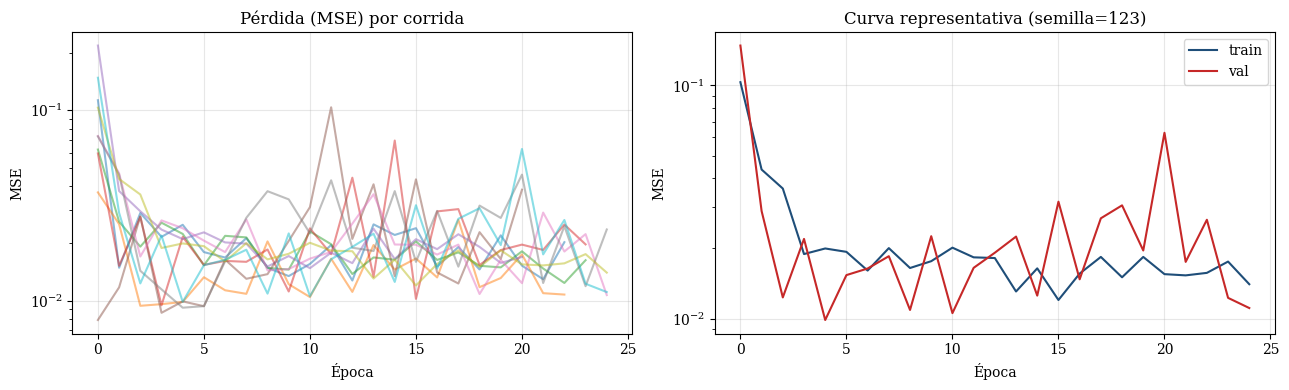

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for h in historias:
    axes[0].plot(h["loss"],     alpha=0.5)
    axes[0].plot(h["val_loss"], alpha=0.5)
axes[0].set_title("Pérdida (MSE) por corrida")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE"); axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")

# La última corrida vs val
axes[1].plot(historias[-1]["loss"],     label="train", color="#1f4e79")
axes[1].plot(historias[-1]["val_loss"], label="val",   color="#c62828")
axes[1].set_title(f"Curva representativa (semilla={SEMILLAS[-1]})")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("MSE")
axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("fig_lstm_curvas.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Cálculo de métricas (media ± desviación)

In [16]:
def reportar(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred)
    }

# Métricas por corrida
mae_l, rmse_l, mape_l = [], [], []
for i, pred in enumerate(predicciones_test, start=1):
    r = reportar(y_test_real, pred)
    mae_l.append(r["MAE"]); rmse_l.append(r["RMSE"]); mape_l.append(r["MAPE"])
    print(f"  Corrida {i}: MAE={r['MAE']:.2f}  RMSE={r['RMSE']:.2f}  MAPE={r['MAPE']:.2f}%")

# Métricas con la predicción promediada (más robusta para reportar)
r_media = reportar(y_test_real, pred_test_media)

print(f"\nResultados sobre TEST ({N_CORRIDAS} corridas):")
print(f"  MAE  = {np.mean(mae_l):8.2f} ± {np.std(mae_l):.2f} GWh  (predicción promedio: {r_media['MAE']:.2f})")
print(f"  RMSE = {np.mean(rmse_l):8.2f} ± {np.std(rmse_l):.2f} GWh  (predicción promedio: {r_media['RMSE']:.2f})")
print(f"  MAPE = {np.mean(mape_l):8.2f} ± {np.std(mape_l):.2f}%    (predicción promedio: {r_media['MAPE']:.2f}%)")


  Corrida 1: MAE=249.76  RMSE=339.54  MAPE=11.98%
  Corrida 2: MAE=250.13  RMSE=332.44  MAPE=11.95%
  Corrida 3: MAE=287.29  RMSE=376.71  MAPE=13.73%
  Corrida 4: MAE=246.23  RMSE=335.31  MAPE=11.82%
  Corrida 5: MAE=242.46  RMSE=325.25  MAPE=11.62%

Resultados sobre TEST (5 corridas):
  MAE  =   255.17 ± 16.29 GWh  (predicción promedio: 248.55)
  RMSE =   341.85 ± 18.04 GWh  (predicción promedio: 340.65)
  MAPE =    12.22 ± 0.77%    (predicción promedio: 11.95%)


## 8. Gráfico de predicción

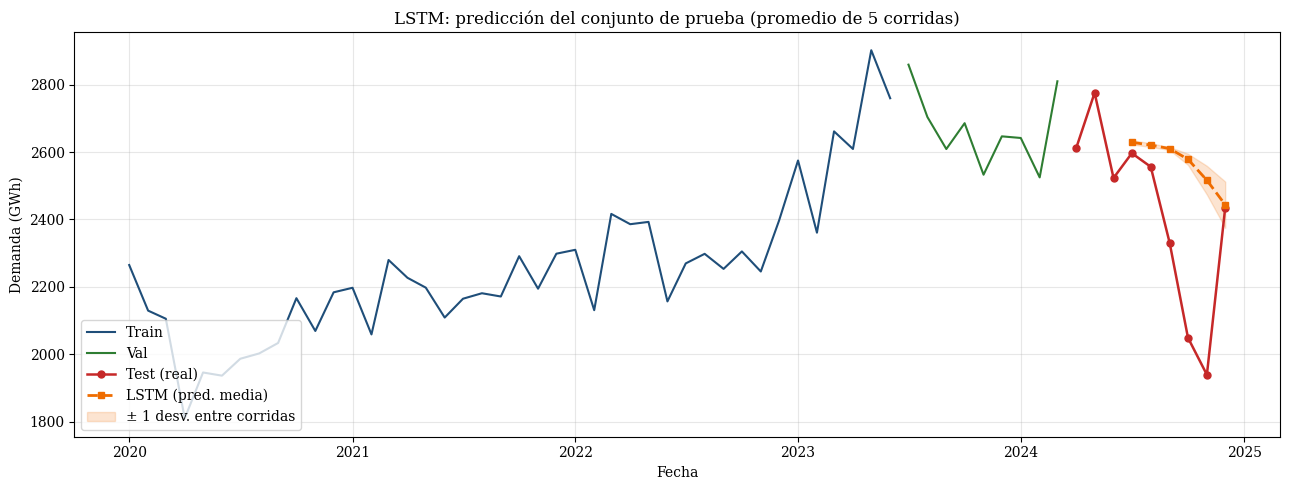

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
# NOTA 1: usamos ax.plot() (no .plot() de pandas) en TODAS las series.
# Mezclar .plot() de pandas con ax.plot() para fechas causa que ambos usen
# conversores de eje X distintos (pandas fija el eje a enteros tipo Period,
# mientras que ax.plot con datetimes usa el formato nativo de matplotlib),
# lo que deja la segunda serie fuera del rango visible del eje X (invisible,
# aunque sí aparece en la leyenda).
#
# NOTA 2: X_test/y_test tienen menos muestras que test_orig porque las
# primeras VENTANA - (len(val) - ...) fechas de test se usan únicamente
# como contexto (lookback) para poder formar la primera ventana completa;
# no todas las fechas de test tienen una predicción asociada. Por eso
# alineamos con las ÚLTIMAS len(pred_test_media) fechas de test, no con
# todas.
fechas_pred = test_orig.index[-len(pred_test_media):]

ax.plot(train_orig.index, train_orig.values, label="Train", color="#1f4e79", lw=1.5)
ax.plot(val_orig.index,   val_orig.values,   label="Val",   color="#2e7d32", lw=1.5)
ax.plot(test_orig.index,  test_orig.values,  label="Test (real)", color="#c62828", lw=1.8, marker="o", ms=5)
ax.plot(fechas_pred, pred_test_media,
        label="LSTM (pred. media)", color="#ef6c00", lw=2.0, marker="s", ms=5, linestyle="--")
ax.fill_between(fechas_pred,
                pred_test_media - pred_test_std,
                pred_test_media + pred_test_std,
                color="#ef6c00", alpha=0.18, label="± 1 desv. entre corridas")
ax.set_title(f"LSTM: predicción del conjunto de prueba (promedio de {N_CORRIDAS} corridas)")
ax.set_ylabel("Demanda (GWh)"); ax.set_xlabel("Fecha"); ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_lstm_prediccion.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Exportación de resultados

In [18]:
resultados_lstm = pd.DataFrame({
    "fecha": fechas_pred,
    "real_gwh": y_test_real,
    "lstm_pred_media_gwh": pred_test_media,
    "lstm_pred_std_gwh":   pred_test_std,
})
resultados_lstm.to_csv("resultados_lstm.csv", index=False)

metricas_lstm = pd.DataFrame({
    "modelo": ["LSTM"]*3,
    "conjunto": ["test"]*3,
    "métrica": ["MAE", "RMSE", "MAPE"],
    "media":      [np.mean(mae_l), np.mean(rmse_l), np.mean(mape_l)],
    "std":        [np.std(mae_l),  np.std(rmse_l),  np.std(mape_l)],
    "pred_promedio": [r_media["MAE"], r_media["RMSE"], r_media["MAPE"]],
})
metricas_lstm.to_csv("metricas_lstm.csv", index=False)

config = {
    "modelo": "LSTM",
    "unidades": int(mejor.unidades),
    "dropout": float(mejor.dropout),
    "learning_rate": float(mejor.lr),
    "batch_size": int(mejor.batch_size),
    "ventana_meses": VENTANA,
    "horizonte_meses": HORIZONTE,
    "n_corridas": N_CORRIDAS,
    "semillas": SEMILLAS
}
with open("config_lstm.json", "w") as f:
    json.dump(config, f, indent=2)

print("Exportado:")
print("  resultados_lstm.csv  (predicciones media y std)")
print("  metricas_lstm.csv    (MAE, RMSE, MAPE con media y std)")
print("  config_lstm.json     (hiperparámetros y arquitectura)")
print("  fig_lstm_prediccion.png, fig_lstm_curvas.png")
print("\nNotebook 3 completado. Continúa con Notebook 4 (comparación final).")


Exportado:
  resultados_lstm.csv  (predicciones media y std)
  metricas_lstm.csv    (MAE, RMSE, MAPE con media y std)
  config_lstm.json     (hiperparámetros y arquitectura)
  fig_lstm_prediccion.png, fig_lstm_curvas.png

Notebook 3 completado. Continúa con Notebook 4 (comparación final).
